<a href="https://colab.research.google.com/github/Sakanksh/Stock-Price-Predictor/blob/main/StockPricePredictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


dataset = pd.read_csv("/content/TSLA.csv")
dataset.head()


,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,3.800,5.000,3.508,4.778,4.778,93831500
1,2010-06-30,5.158,6.084,4.660,4.766,4.766,85935500
2,2010-07-01,5.000,5.184,4.054,4.392,4.392,41094000
3,2010-07-02,4.600,4.620,3.742,3.840,3.840,25699000
4,2010-07-06,4.000,4.000,3.166,3.222,3.222,34334500


In [ ]:
training = dataset.iloc[:,1:2].values
print(training)
print(training.shape)

[[   3.8     ]
 [   5.158   ]
 [   5.      ]
 ...
 [ 930.      ]
 [ 979.940002]
 [1009.72998 ]]
(2956, 1)


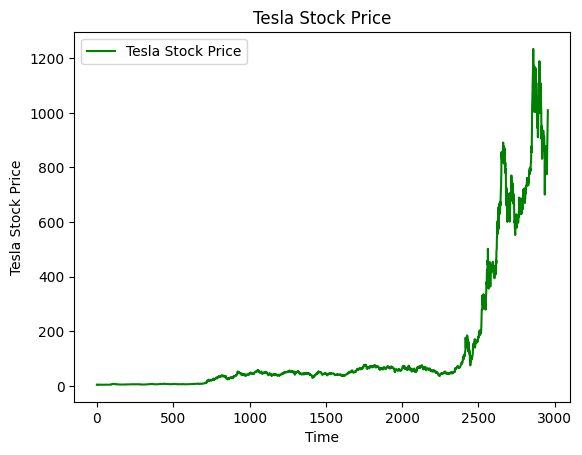

In [ ]:
plt.plot(training, color = 'green', label='Tesla Stock Price')
plt.title('Tesla Stock Price')
plt.xlabel('Time')
plt.ylabel('Tesla Stock Price')
plt.legend()

In [ ]:

from sklearn.model_selection import train_test_split

train_size = int(len(dataset) * 0.8)

dataset_train = dataset.iloc[:train_size]
dataset_test = dataset.iloc[train_size:]


dataset_train.to_csv('/content/TSLA_train.csv', index=False)
dataset_test.to_csv('/content/TSLA_test.csv', index=False)

print("Training data:", dataset_train.shape)
print("Testing data:", dataset_test.shape)

Training data: (2364, 7)
Testing data: (592, 7)


In [ ]:
dataset_train = pd.read_csv('/content/TSLA_train.csv')
dataset_train.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,3.800,5.000,3.508,4.778,4.778,93831500
1,2010-06-30,5.158,6.084,4.660,4.766,4.766,85935500
2,2010-07-01,5.000,5.184,4.054,4.392,4.392,41094000
3,2010-07-02,4.600,4.620,3.742,3.840,3.840,25699000
4,2010-07-06,4.000,4.000,3.166,3.222,3.222,34334500


In [ ]:
training_set = dataset_train.iloc[:,1:2].values
print(training_set)
print(training_set.shape)

[[ 3.8     ]
 [ 5.158   ]
 [ 5.      ]
 ...
 [71.      ]
 [69.222   ]
 [70.127998]]
(2364, 1)


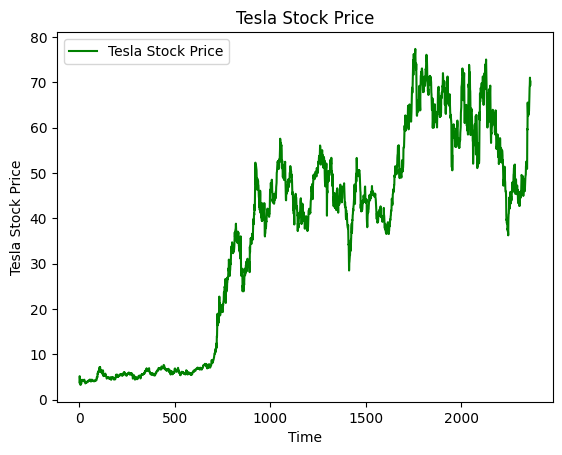

In [ ]:
plt.plot(training_set, color = 'green', label='Tesla Stock Price')
plt.title('Tesla Stock Price')
plt.xlabel('Time')
plt.ylabel('Tesla Stock Price')
plt.legend()


In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))
scaled_training_set = scaler.fit_transform(training_set)
scaled_training_set

array([[0.00771826],
       [0.02604237],
       [0.0239104 ],
       ...,
       [0.91447851],
       [0.89048715],
       [0.90271219]])

In [ ]:
X_train = []
y_train = []
for i in range(60, 1259):
  X_train.append(scaled_training_set[i-60:i,0])
  y_train.append(scaled_training_set[i,0])
X_train = np.array(X_train)
y_train = np.array(y_train)
print(X_train.shape)
print(y_train.shape)

(1199, 60)
(1199,)


In [ ]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_train.shape

(1199, 60, 1)

In [ ]:
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from keras.layers import Dropout
regressor = Sequential()
regressor.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1],1)))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=50))
regressor.add(Dropout(0.2))
regressor.add(Dense(units=1))
regressor.compile(optimizer='adam', loss='mean_squared_error')
regressor.fit(X_train, y_train, epochs=100, batch_size=32)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.0190
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0027
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0025
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0024
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0024
Epoch 6/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0024
Epoch 7/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0023
Epoch 8/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0021
Epoch 9/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0021
Epoch 10/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0019
Epoch 11/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0018
Epoch 12/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0020
Epoch 13/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0018
Epoch 14/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0018
Epoch 15/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - lo

In [ ]:
dataset_test = pd.read_csv('/content/TSLA_test.csv')
real_stock_price = dataset_test.iloc[:,1:2].values
dataset_total = pd.concat((dataset_train['Open'], dataset_test['Open']), axis=0)
inputs = dataset_total[len(dataset_total) - len(dataset_test) - 60:].values
inputs = inputs.reshape(-1,1)
inputs = scaler.transform(inputs)

X_test = []
for i in range(60, 80):
  X_test.append(inputs[i-60:i,0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = scaler.inverse_transform(predicted_stock_price)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step


In [ ]:
real_stock_price = np.delete(real_stock_price, 20, axis = 0)
print(real_stock_price)

[[  70.584   ]
 [  70.349998]
 [  72.      ]
 [  70.902   ]
 [  68.031998]
 [  68.863998]
 [  67.054001]
 [  66.223999]
 [  66.222   ]
 [  65.879997]
 [  66.524002]
 [  67.550003]
 [  66.566002]
 [  67.      ]
 [  67.318001]
 [  67.991997]
 [  70.375999]
 [  70.984001]
 [  72.209999]
 [  72.510002]
 [  76.125999]
 [  79.463997]
 [  82.057999]
 [  82.356003]
 [  83.671997]
 [  85.582001]
 [  87.      ]
 [  85.758003]
 [  81.      ]
 [  84.900002]
 [  88.099998]
 [  88.094002]
 [  92.279999]
 [  94.739998]
 [  99.419998]
 [  96.358002]
 [  98.699997]
 [ 108.851997]
 [ 105.952003]
 [  98.75    ]
 [ 101.522003]
 [ 106.050003]
 [ 114.377998]
 [ 112.849998]
 [ 114.125999]
 [ 108.398003]
 [ 113.697998]
 [ 115.138   ]
 [ 126.484001]
 [ 128.      ]
 [ 134.738007]
 [ 176.591995]
 [ 164.651993]
 [ 139.983994]
 [ 146.110001]
 [ 160.      ]
 [ 153.757996]
 [ 155.574005]
 [ 148.367996]
 [ 157.444   ]
 [ 168.320007]
 [ 184.699997]
 [ 182.389999]
 [ 181.395996]
 [ 167.800003]
 [ 169.800003]
 [ 156.5  

In [ ]:
first_20_real_stock_price = real_stock_price[:20]

print(first_20_real_stock_price)

[[70.584   ]
 [70.349998]
 [72.      ]
 [70.902   ]
 [68.031998]
 [68.863998]
 [67.054001]
 [66.223999]
 [66.222   ]
 [65.879997]
 [66.524002]
 [67.550003]
 [66.566002]
 [67.      ]
 [67.318001]
 [67.991997]
 [70.375999]
 [70.984001]
 [72.209999]
 [72.510002]]


In [ ]:
print(predicted_stock_price)

[[68.64196 ]
 [68.72499 ]
 [68.81154 ]
 [69.54006 ]
 [69.74882 ]
 [68.69366 ]
 [68.07406 ]
 [67.177956]
 [66.35482 ]
 [65.918365]
 [65.70002 ]
 [65.87683 ]
 [66.45676 ]
 [66.55315 ]
 [66.55226 ]
 [66.57348 ]
 [66.79949 ]
 [67.837814]
 [68.90848 ]
 [69.95594 ]]


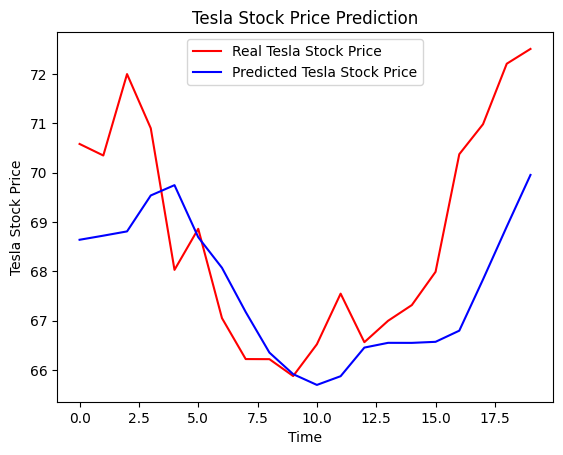

In [ ]:
plt.plot(first_20_real_stock_price, color = 'red', label='Real Tesla Stock Price')
plt.plot(predicted_stock_price, color = 'blue', label='Predicted Tesla Stock Price')
plt.title('Tesla Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Tesla Stock Price')
plt.legend()